### 静态分支 & 动态分支

图执行时，「下一步走哪个（些）节点」有两种决定方式：

| | 静态分支 | 动态分支 |
| --- | --- | --- |
| 决定时机 | **编译前**（写死在图里） | **运行时**（根据当前 state 计算） |
| 实现方式 | `add_edge(A, B)` | `add_conditional_edges` / `Command(goto=...)` / `Send(...)` |
| 拓扑 | 固定不变 | 每个输入可能不同 |
| 典型用途 | 线性流程、固定并行 fan-out/fan-in | if/else 路由、循环、动态 fan-out（map-reduce）、工具调用 |

一句话：**静态分支是「边写好了」，动态分支是「运行时算出来」。** 下面分别演示。

### 0. 公共导入与画图工具

In [1]:
from typing import TypedDict, Annotated, Literal, Sequence
from operator import add

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, Send


def show(graph):
    # 渲染图结构；离线时退化为打印 mermaid 文本
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("跳过图形渲染：", e)
        print(graph.get_graph().draw_mermaid())

### 一、静态分支：拓扑写死在图里

`add_edge` 定义的边在**编译时就固定**了。下面是一个**固定 fan-out / fan-in**：
`START` 同时进入 `fetch_a`、`fetch_b` 并行执行，两者都汇入 `merge`——
不管输入是什么，走的都是这几条边。

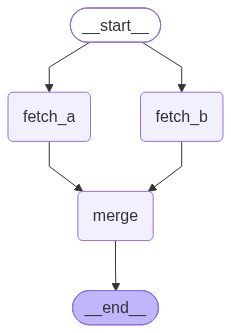

{'logs': ['fetch_a', 'fetch_b', 'merge']}


In [2]:
class StaticState(TypedDict):
    logs: Annotated[list[str], add]


def fetch_a(state: StaticState) -> dict:
    return {"logs": ["fetch_a"]}


def fetch_b(state: StaticState) -> dict:
    return {"logs": ["fetch_b"]}


def merge(state: StaticState) -> dict:
    return {"logs": ["merge"]}


static = StateGraph(StaticState)
static.add_node("fetch_a", fetch_a)
static.add_node("fetch_b", fetch_b)
static.add_node("merge", merge)
static.add_edge(START, "fetch_a")
static.add_edge(START, "fetch_b")
# 固定 fan-out
static.add_edge("fetch_a", "merge")
static.add_edge("fetch_b", "merge")
static.add_edge("merge", END)  # 固定出口

static_graph = static.compile()
show(static_graph)
print(static_graph.invoke({"logs": []}))

> **为什么不用 `add_sequence` 简化？**
>
> `add_sequence` 只处理**线性链**，而本图是 fan-out/fan-in（`merge` 有两个前驱）。
> 若写成两个序列 `add_sequence([fetch_a, merge])` + `add_sequence([fetch_b, merge])`，
> 第二个序列会因 `merge` 已存在而抛 `ValueError: Node names must be unique`。
> 它只适合 `START -> a -> b -> END` 这样的直线流程。

### 二、动态分支①：`add_conditional_edges`（运行时 if/else）

路由函数接收当前 state，返回下一个节点名（或 `END`）。
`path_map` 把返回值映射到实际节点名；若返回值直接就是节点名，可省略。

下面按 `score` 路由：≥60 走 `praise`，否则走 `fail`。

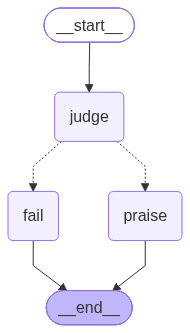

高分: {'logs': ['评分=90', 'praise：通过'], 'score': 90}
低分: {'logs': ['评分=10', 'fail：未通过'], 'score': 10}


In [3]:
class RouteState(TypedDict):
    logs: Annotated[list[str], add]
    score: int


def judge(state: RouteState) -> dict:
    return {"logs": [f"评分={state['score']}"]}


def praise(state: RouteState) -> dict:
    return {"logs": ["praise：通过"]}


def fail(state: RouteState) -> dict:
    return {"logs": ["fail：未通过"]}


def by_score(state: RouteState) -> str:
    # 运行时决定下一步 —— “动态”就来自这里
    return "praise" if state["score"] >= 60 else "fail"


route_builder = StateGraph(RouteState)
route_builder.add_node("judge", judge)
route_builder.add_node("praise", praise)
route_builder.add_node("fail", fail)
route_builder.add_edge(START, "judge")
route_builder.add_conditional_edges(
    "judge",
    by_score,
    {"praise": "praise", "fail": "fail"},  # path_map: 返回值 -> 节点
)
route_builder.add_edge("praise", END)
route_builder.add_edge("fail", END)

route_graph = route_builder.compile()
show(route_graph)
print("高分:", route_graph.invoke({"logs": [], "score": 90}))
print("低分:", route_graph.invoke({"logs": [], "score": 10}))

#### 同一个路由函数也能返回 `END`，用来做「循环 + 终止条件」

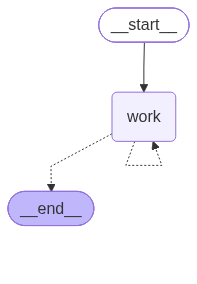

{'logs': ['第 1 次执行', '第 2 次执行', '第 3 次执行'], 'count': 3}


In [4]:
class LoopState(TypedDict):
    logs: Annotated[list[str], add]
    count: int


def work(state: LoopState) -> dict:
    n = state["count"] + 1
    return {"count": n, "logs": [f"第 {n} 次执行"]}


def should_continue(state: LoopState) -> str:
    # 未达次数就回去继续，达到就结束
    return "work" if state["count"] < 3 else END


loop_builder = StateGraph(LoopState)
loop_builder.add_node("work", work)
loop_builder.add_edge(START, "work")
loop_builder.add_conditional_edges("work", should_continue, {"work": "work", END: END})
loop_graph = loop_builder.compile()
show(loop_graph)
print(loop_graph.invoke({"logs": [], "count": 0}))

### 三、动态分支②：`Command(goto=...)`（路由 + 更新状态一步完成）

`add_conditional_edges` 只能路由、不能更新状态；`Command` 可以在**同一个节点里**
既更新 state 又决定去向，常见于「处理完顺手跳转」或工具节点。

- 返回类型标注 `Command[Literal["a", "b"]]`，图才能画出动态边；
- `Command` 与静态 `add_edge` **不要**用在同一个节点的出边，否则两条路都会执行。

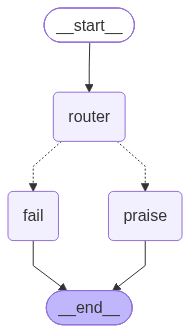

高分: {'logs': ['router -> praise', 'praise：通过'], 'score': 90}
低分: {'logs': ['router -> fail', 'fail：未通过'], 'score': 10}


In [5]:
def router(state: RouteState) -> Command[Literal["praise", "fail"]]:
    # update 更新状态，goto 决定去向，一次完成
    if state["score"] >= 60:
        return Command(goto="praise", update={"logs": ["router -> praise"]})
    return Command(goto="fail", update={"logs": ["router -> fail"]})


command_builder = StateGraph(RouteState)
command_builder.add_node("router", router)
command_builder.add_node("praise", praise)
command_builder.add_node("fail", fail)
command_builder.add_edge(START, "router")
command_builder.add_edge("praise", END)
command_builder.add_edge("fail", END)

command_graph = command_builder.compile()
show(command_graph)
print("高分:", command_graph.invoke({"logs": [], "score": 90}))
print("低分:", command_graph.invoke({"logs": [], "score": 10}))

### 四、动态分支③：`Send`（动态 fan-out / map-reduce）

静态 fan-out 的分支数量是写死的；`Send` 可以**按运行时数据决定开多少个并行分支**。
路由函数返回一个 `Send` 列表，每个 `Send(节点, payload)` 会把 payload 当作该分支的 state。

- 要有一个**真实的源节点**，把 `Send` 路由函数挂在它后面（不能直接把 `Send` 当节点）；
- 各分支结果用 reducer 汇总（这里是 `results` 的 `add`）。

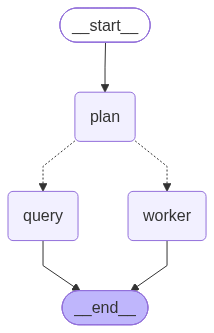

{'items': ['a', 'b', 'c'], 'results': ['处理: a', '处理: b', '处理: c', '查询: a', '查询: b', '查询: c']}


In [6]:
class MapState(TypedDict):
    items: Annotated[list[str], add]
    results: Annotated[list[str], add]


def plan(state: MapState) -> dict:
    return {
        "items": ["a", "b", "c"],
    }  # 真实节点：作为动态 fan-out 的源


def dispatch(state: MapState) -> Sequence[Send]:
    # 有几个 item 就开几个 worker，数量由运行时决定
    return [Send("worker", {"item": item}) for item in state["items"]] + [Send("query", {"item": item}) for item in
                                                                          state["items"]]


def worker(state: MapState) -> dict:
    return {"results": [f"处理: {state['item']}"]}


def query(state: MapState) -> dict:
    return {"results": [f"查询: {state['item']}"]}


map_builder = StateGraph(MapState)
map_builder.add_node("plan", plan)
map_builder.add_node("worker", worker)
map_builder.add_node("query", query)
map_builder.add_conditional_edges("plan", dispatch, {"worker": "worker", "query": "query"})
map_builder.add_edge(START, "plan")
map_builder.add_edge("worker", END)
map_builder.add_edge("query", END)

map_graph = map_builder.compile()
show(map_graph)
print(map_graph.invoke({"items": [], "results": []}))

### 五、动态分支④：`Send` 配合工具调用

`Send` 最常见的落地场景就是 **map-reduce + 工具**：把一批任务并行发给同一个节点，
每个分支调用一次工具，再把结果用 reducer 汇总。

这里用一个 `@tool` 定义的普通工具演示（不依赖 LLM / 网络）：
`prepare` 生成待处理数字，`dispatch` 为每个数字发一个 `Send`，`tool_worker` 调用 `square` 工具。


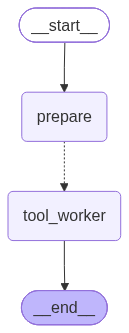

{'numbers': [1, 2, 3, 4], 'results': ['1^2 = 1', '2^2 = 4', '3^2 = 9', '4^2 = 16']}


In [7]:
from langchain_core.tools import tool


@tool
def square(x: int) -> int:
    """计算 x 的平方"""
    return x * x


class ToolMapState(TypedDict):
    numbers: list[int]
    results: Annotated[list[str], add]


def prepare(state: ToolMapState) -> dict:
    return {"numbers": [1, 2, 3, 4]}  # 生成待处理任务


def dispatch(state: ToolMapState):
    # 每个数字一个 Send，各自带一份独立的 payload
    return [Send("tool_worker", {"number": n}) for n in state["numbers"]]


def tool_worker(state: ToolMapState) -> dict:
    r = square.invoke({"x": state["number"]})  # 调用工具
    return {"results": [f"{state['number']}^2 = {r}"]}


tool_builder = StateGraph(ToolMapState)
tool_builder.add_node("prepare", prepare)
tool_builder.add_node("tool_worker", tool_worker)
tool_builder.add_conditional_edges("prepare", dispatch, ["tool_worker"])
tool_builder.add_edge(START, "prepare")
tool_builder.add_edge("tool_worker", END)

tool_graph = tool_builder.compile()
show(tool_graph)
print(tool_graph.invoke({"numbers": [], "results": []}))


> **进阶**：真实 agent 里常把 `Send` 的目标指向一个调用 `ToolNode` 或**绑定工具的 LLM 节点**，
> 即「每个子任务由一个小 agent 处理」的 map-reduce 多智能体模式。
> 本示例用确定性工具，便于离线复现核心机制。


### 小结：如何选择

| 场景 | 推荐 |
| --- | --- |
| 固定流程 / 固定并行 | **静态分支** `add_edge` |
| 根据状态 if/else、循环终止 | **动态** `add_conditional_edges` |
| 既要更新状态又要跳转（工具、handoff） | **动态** `Command(goto=...)` |
| 分支数量由数据决定（map-reduce） | **动态** `Send(...)` |

**注意事项**

1. 同一个节点不要同时用静态 `add_edge` 和 `Command` / 条件边，否则两路都会执行。
2. 循环必须有终止条件（路由函数返回 `END`），否则会死循环。
3. 动态分支写同一个 state key 时同样需要 reducer（参见 `04-节点并行执行`）。